# Ligand-based vs Structure-based Reward

## Abstract

Notebook 13 showed that a docking reward drives generation toward large, lipophilic molecules. This notebook asks what the choice of potency signal actually buys, by comparing four rewards that share the same quality terms (QED and synthetic accessibility) and the same pessimistic lower-confidence-bound form, and differ only in how potency is scored: a ligand-based QSAR pIC50, a structure-based docking score, docking with an added logD window, and docking normalized per heavy atom (ligand efficiency). Each reward is run over five REINVENT replicates, and every generated population is docked for real and profiled on pIC50, drug-likeness, lipophilicity, size, synthesizability and scaffold diversity. The two oracles are not interchangeable: the docking reward reaches better docking at a developability cost, while the QSAR reward stays drug-like without winning on pIC50. The soft logD guard barely moves the drift, diluted inside the geometric mean. Ligand efficiency corrects it at the source, collapsing molecular weight and lipophilicity, but it trades absolute binding and scaffold diversity for that gain. No single scalar objective is a good drug objective; each one moves the failure elsewhere.

## Introduction

A generative agent needs a potency signal, and the two standard choices come from different places. A ligand-based QSAR model learns pIC50 from known actives. A structure-based docking score estimates binding into the pocket. They are often treated as interchangeable rewards, but they carry different biases. This notebook makes the comparison explicit and fair, holds everything constant except the potency term, and then tests two ways of correcting the docking bias identified in notebook 13: an explicit property guard and a reframed objective.

## Methods

Four reward objectives are compared. All share two fixed quality terms, drug-likeness (QED) and synthetic accessibility, combined by a renormalized geometric mean, and all score potency as a pessimistic lower confidence bound μ − λσ. They differ only in the potency signal: the notebook-06 QSAR pIC50 (`activity`), the docking surrogate (`dock`), the docking surrogate with an added logD window (`dock,logd`), and the docking surrogate normalized per heavy atom (`dock_le`, ligand efficiency). The docking-reward arm reuses the pessimistic runs of notebook 13.

Ligand efficiency is defined as the pessimistic docking score divided by the heavy-atom count, LE = (μ − λσ) / HAC, mapped to a desirability by a sigmoid. Its center and width are calibrated to the median and interquartile range of LE over the docking set (next cell), so that the term discriminates across the range actually seen. Each objective is run over five independent REINVENT replicates (RNN prior on PubChem, DAP, σ = 128, 190 steps, batch 64). The final population of every run is docked for real, and each molecule is profiled on predicted pIC50, QED, logP, molecular weight, synthetic accessibility, xTB stability, novelty, and per-run scaffold diversity.

In [1]:
import os, subprocess, glob
import sys; sys.path.append("/mnt/c/Users/coure/Projects/cheminformatics")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import scoring.scorer as sc
import re

REPO         = "/mnt/c/Users/coure/Projects/cheminformatics"
REINVENT_DIR = "/home/couret/REINVENT4"
ENV_REINVENT = "reinvent4"
ENV_DOCK     = "dock"
DOCK_WORKER  = f"{REPO}/dock_seed/dock_worker.py"
RUN_SUBDIR   = "dock_runs"
CMP_CSV      = f"{REPO}/rl_runs/cmp_pic50_dock.csv"
CONDA = os.environ.get("CONDA_EXE") or os.path.expanduser("~/miniconda3/bin/conda")  

TEMPLATE = '''run_type = "staged_learning"
device = "cpu"
tb_logdir = "tb_logs"

[parameters]
summary_csv_prefix = "{subdir}/{name}"
use_checkpoint = false
purge_memories = false
prior_file = "priors/reinvent.prior"
agent_file = "priors/reinvent.prior"
batch_size = 64
randomize_smiles = true

[learning_strategy]
type = "dap"
sigma = 128
rate = 0.0001

[[stage]]
chkpt_file = "{subdir}/{name}.chkpt"
termination = "simple"
max_score = 1.0
min_steps = {steps}
max_steps = {steps}

[stage.scoring]
type = "geometric_mean"

[[stage.scoring.component]]
[stage.scoring.component.Scorer]
[[stage.scoring.component.Scorer.endpoint]]
name = "{name}"
weight = 1
[stage.scoring.component.Scorer.endpoint.params]
terms = "{terms_csv}"
combine = "geometric"
'''

def run_reinvent(name, terms_csv, steps=190):
    toml = TEMPLATE.replace("exp_pess_s0", name)
    toml = re.sub(r'terms = "[^"]*"', f'terms = "{terms_csv}"', toml)
    open(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}.toml", "w").write(toml)
    subprocess.run([CONDA, "run", "-n", ENV_REINVENT, "reinvent", f"{RUN_SUBDIR}/{name}.toml"],
        cwd=REINVENT_DIR, check=True,
        env={**os.environ, "MPLBACKEND": "Agg", "PYTHONPATH": f"{REINVENT_DIR}/contrib"})

def dock_batch(smiles, tag):
    work = f"{REPO}/dock_seed/_{tag}.smi"
    open(work, "w").write("\n".join(smiles) + "\n")
    subprocess.run([CONDA, "run", "-n", ENV_DOCK, "python", DOCK_WORKER, work],
        check=True, env={**os.environ, "NCORES": str(os.cpu_count())})
    d = pd.read_csv(work.replace(".smi", "_out.csv")).dropna(subset=["affinity"])
    return dict(zip(d["smiles"], d["affinity"]))

def final_pop(name, n=160):
    df = pd.read_csv(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv").dropna(subset=["SMILES"])
    df["step"] = np.arange(len(df)) // 64
    return df[df["step"] >= df["step"].max()*0.75]["SMILES"].drop_duplicates().tolist()[:n]

def pic50(smi):
    m = Chem.MolFromSmiles(smi)
    return float(np.mean([mm.predict(sc.feat(m))[0] for mm in sc.ensemble])) if m else np.nan

In [2]:
d = pd.read_csv(f"{REPO}/models/docking_seed.csv").sample(500, random_state=0)
le = [(-a)/Chem.MolFromSmiles(s).GetNumHeavyAtoms()
      for s, a in zip(d.smiles, d.affinity) if Chem.MolFromSmiles(s)]
print("LE median", np.median(le).round(3), "| IQR", np.round(np.quantile(le,[.25,.75]),3))

LE median 0.35 | IQR [0.308 0.406]


In [3]:
def collect(name, objective, seed, aff):
    rows = []
    for s in final_pop(name):
        m = Chem.MolFromSmiles(s)
        if m is None or s not in aff: continue
        rows.append(dict(objective=objective, seed=seed, smiles=s,
                         dock=-aff[s], pIC50=pic50(s),
                         QED=QED.qed(m), logP=Crippen.MolLogP(m), MW=Descriptors.MolWt(m)))
    return rows

rows = pd.read_csv(CMP_CSV).to_dict("records") if os.path.exists(CMP_CSV) else []
done = {(r["objective"], r["seed"]) for r in rows}

for s in range(5):
    # --- pIC50-reward arm (new runs) ---
    if ("pIC50-reward", s) not in done:
        name = f"exp_pic50_s{s}"
        if not os.path.exists(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv"):
            run_reinvent(name, "activity,qed,sa")
        aff = dock_batch(final_pop(name), tag=f"cmp_{name}")
        rows += collect(name, "pIC50-reward", s, aff)
        pd.DataFrame(rows).to_csv(CMP_CSV, index=False)
    # --- docking-reward arm (reuse NB13 exp_pess + existing docking) ---
    if ("docking-reward", s) not in done:
        d = pd.read_csv(f"{REPO}/dock_seed/_eval_exp_pess_s{s}_out.csv").dropna(subset=["affinity"])
        rows += collect(f"exp_pess_s{s}", "docking-reward", s, dict(zip(d["smiles"], d["affinity"])))
        pd.DataFrame(rows).to_csv(CMP_CSV, index=False)
    # --- docking + logD guard arm (new runs) ---
    if ("docking+logD", s) not in done:
        name = f"exp_docklogd_s{s}"
        if not os.path.exists(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv"):
            run_reinvent(name, "dock,qed,sa,logd")
        aff = dock_batch(final_pop(name), tag=f"cmp_{name}")
        rows += collect(name, "docking+logD", s, aff)
        pd.DataFrame(rows).to_csv(CMP_CSV, index=False)
    # --- docking ligand-efficiency arm (new runs) ---
    if ("docking-LE", s) not in done:
        name = f"exp_dockle_s{s}"
        if not os.path.exists(f"{REINVENT_DIR}/{RUN_SUBDIR}/{name}_1.csv"):
            run_reinvent(name, "dock_le,qed,sa")
        aff = dock_batch(final_pop(name), tag=f"cmp_{name}")
        rows += collect(name, "docking-LE", s, aff)
        pd.DataFrame(rows).to_csv(CMP_CSV, index=False)

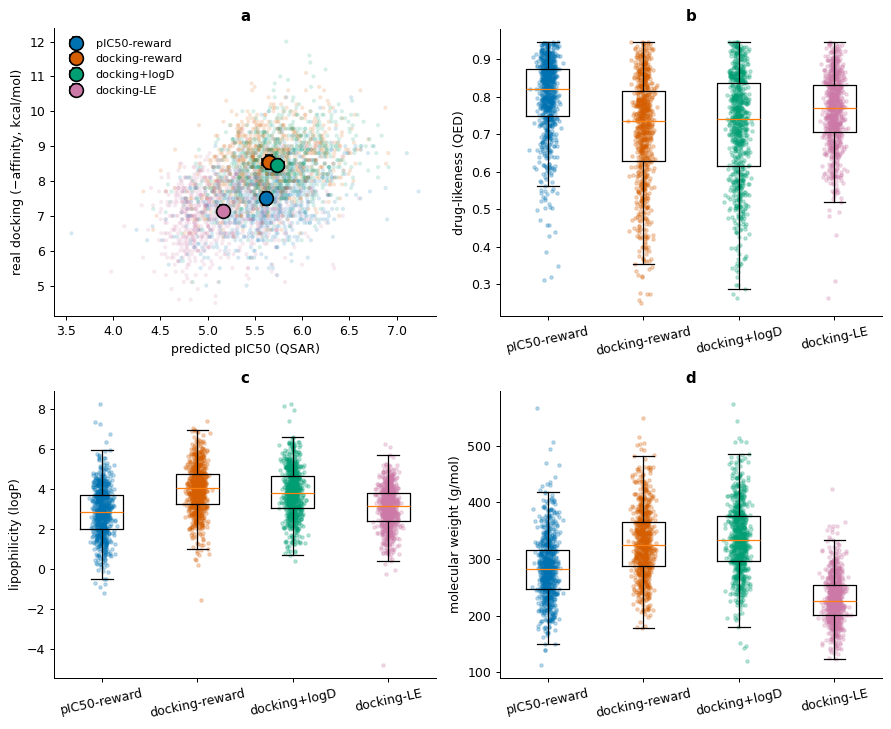

In [4]:
rng = np.random.default_rng(0)
cmp = pd.read_csv(CMP_CSV)
colors = {"pIC50-reward": "#0072B2", "docking-reward": "#D55E00", "docking+logD": "#009E73", "docking-LE": "#CC79A7"}
order  = ["pIC50-reward", "docking-reward", "docking+logD", "docking-LE"]

def mean_ci(d, col):
    per = d.groupby("seed")[col].mean().values
    return per.mean(), 1.96*per.std(ddof=1)/np.sqrt(len(per))

plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False})
fig, ax = plt.subplots(2, 2, figsize=(10, 8.2))

A = ax[0, 0]
for o in order:
    d = cmp[cmp.objective == o]
    A.scatter(d["pIC50"], d["dock"], s=11, alpha=.16, color=colors[o], edgecolor="none")
    mx, cx = mean_ci(d, "pIC50"); my, cy = mean_ci(d, "dock")
    A.errorbar(mx, my, xerr=cx, yerr=cy, fmt="o", ms=11, color=colors[o],
               mec="k", mew=1.3, ecolor="k", capsize=3, zorder=5, label=o)
A.set_xlabel("predicted pIC50 (QSAR)"); A.set_ylabel("real docking (−affinity, kcal/mol)")
A.set_title("a"); A.legend(fontsize=9)

for a, col, lab, tag in [(ax[0,1], "QED", "drug-likeness (QED)", "b"),
                         (ax[1,0], "logP", "lipophilicity (logP)", "c"),
                         (ax[1,1], "MW", "molecular weight (g/mol)", "d")]:
    a.boxplot([cmp[cmp.objective==o][col] for o in order], tick_labels=order, showfliers=False)
    for i, o in enumerate(order):
        v = cmp[cmp.objective==o][col]
        a.scatter(rng.normal(i+1, .05, len(v)), v, s=7, alpha=.25, color=colors[o])
    a.set_ylabel(lab); a.set_title(tag); a.tick_params(axis="x", rotation=12)

fig.tight_layout()
fig.savefig(f"{REPO}/figures/nb14_pic50_vs_docking.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
def extra(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return pd.Series([np.nan]*3)
    fp = sc.compute_fp(m)
    sa  = sc.sascorer.calculateScore(m)
    xtb = 1.0 - float(sc.xtb_clf.predict_proba(np.asarray(fp).reshape(1, -1))[0, 1])
    nov = 1.0 - max(DataStructs.BulkTanimotoSimilarity(fp, sc.ref_fps))
    return pd.Series([sa, xtb, nov])

cmp[["SA", "xtb_stab", "novelty"]] = cmp["smiles"].apply(extra)

def scdiv(df):
    v = [m for m in (Chem.MolFromSmiles(s) for s in df.smiles) if m]
    return len({MurckoScaffold.MurckoScaffoldSmiles(mol=m) for m in v}) / max(1, len(v))
div = cmp.groupby(["objective", "seed"]).apply(scdiv).reset_index(name="scaffold_div")

/tmp/ipykernel_19879/1178518677.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  div = cmp.groupby(["objective", "seed"]).apply(scdiv).reset_index(name="scaffold_div")


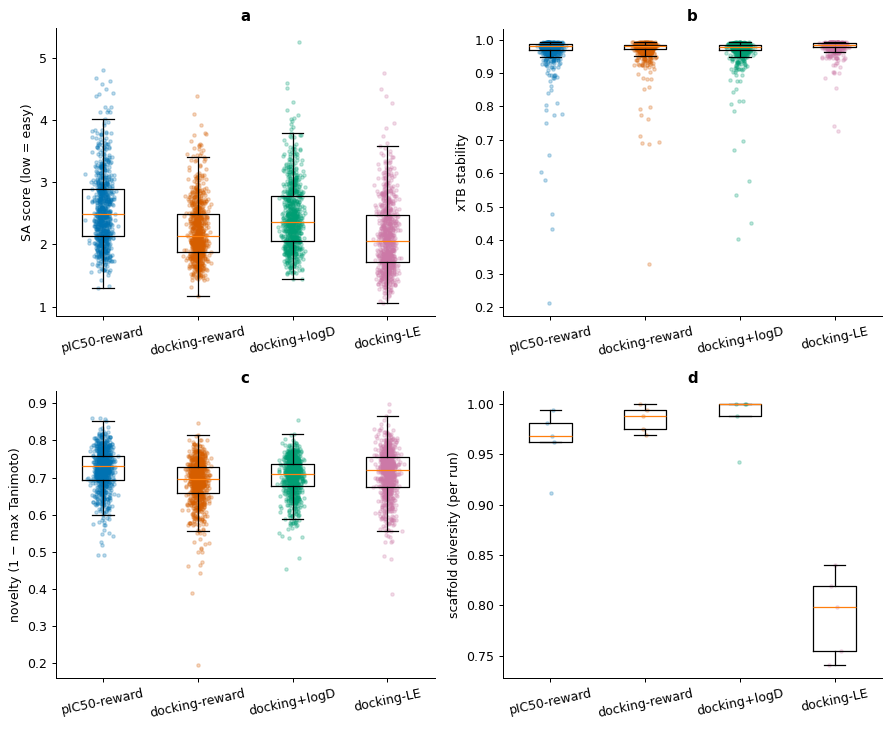

In [6]:
rng = np.random.default_rng(0)
colors = {"pIC50-reward": "#0072B2", "docking-reward": "#D55E00",
          "docking+logD": "#009E73", "docking-LE": "#CC79A7"}
order = ["pIC50-reward", "docking-reward", "docking+logD", "docking-LE"]

plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 12, "axes.titleweight": "bold"})
fig, ax = plt.subplots(2, 2, figsize=(10, 8.2))

def strip(a, df, col, lab, tag, keycol="objective"):
    a.boxplot([df[df[keycol] == o][col] for o in order], tick_labels=order, showfliers=False)
    for i, o in enumerate(order):
        v = df[df[keycol] == o][col]
        a.scatter(rng.normal(i+1, .05, len(v)), v, s=7, alpha=.25, color=colors[o])
    a.set_ylabel(lab); a.set_title(tag); a.tick_params(axis="x", rotation=12)

strip(ax[0, 0], cmp, "SA",       "SA score (low = easy)",        "a")
strip(ax[0, 1], cmp, "xtb_stab", "xTB stability",                "b")
strip(ax[1, 0], cmp, "novelty",  "novelty (1 − max Tanimoto)",   "c")
strip(ax[1, 1], div, "scaffold_div", "scaffold diversity (per run)", "d")

fig.tight_layout()
fig.savefig(f"{REPO}/figures/nb14_secondary_criteria.png", dpi=200, bbox_inches="tight")
plt.show()

## Results

The two oracles optimize partly different things (figure 1.a). Both the pIC50 reward and the docking reward reach the same predicted pIC50 (around 5.6), but the docking reward reaches a better real docking score (about −8.6 vs −7.3 kcal/mol). It pays for this in developability: lower QED, higher logP and higher molecular weight than the QSAR reward (figures 1.b–d). The QSAR reward stays drug-like because it is anchored to real ChEMBL actives, and it does not win on pIC50 over the docking reward. Adding a logD window to the docking reward barely changes the profile: diluted inside a geometric mean of four terms, it cannot counter the strong, confident gradient of docking toward lipophilic bulk.

Ligand efficiency corrects the drift at its source. Normalizing the score per heavy atom collapses molecular weight (median near 235 vs 330 g/mol), lowers logP, raises QED, and gives the lowest SA score of all arms, since the molecules are smaller and simpler to make. The cost appears on two axes. Absolute binding and predicted pIC50 both drop, because small molecules make fewer contacts, and scaffold diversity collapses (about 0.79 against 0.97 to 0.99 for the other arms), because small molecules leave little room for distinct Bemis-Murcko frameworks. xTB stability and novelty stay flat across all conditions, as expected for terms the objective does not touch.

## Discussion

The comparison draws a clean map of the trade-offs. A structure-based reward buys docking score but inflates size and lipophilicity. A ligand-based reward stays drug-like but does not improve the structure-based score. A soft property guard is too weak to redirect an adversarial optimizer when it is one diluted term among several. A reframed objective, ligand efficiency, does redirect it, but it swings the population to the opposite extreme: small, efficient, easy to make, yet weakly binding and structurally repetitive. The failure mode flips rather than disappears.

The honest conclusion is that no single scalar objective yields a lead-like population. Raw potency, whether from docking or QSAR, and per-atom efficiency are endpoints of a spectrum, and good medicinal chemistry lives between them: sufficient absolute potency at good efficiency, within a drug-like size and lipophilicity window. Reaching that region needs a balanced multi-objective, for instance ligand efficiency with a minimum-size floor or absolute docking with a soft molecular-weight window, rather than any one term pushed to its limit. These results are bounded by the usual caveats: docking is an imperfect and itself size-biased oracle, five replicates give low power, and no molecule was validated experimentally.